# Load libraries and data import

Libs

In [1]:
# Load libraries
library(tidyverse)
library(gt)
library(ggridges)
library(pheatmap)
library(RColorBrewer)
library(data.table) 
library(ggplot2)
library(patchwork)
library(scales) 
library(readr)
library(data.table)
library(tibble)
library(pheatmap)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘packag

Import categorical data

In [2]:
# ==========================================
# 1. PATH CONFIGURATIONS
# ==========================================
# Directory containing the processed categorical CSVs
results_import <- "results/categorical_data"

# Directory where visualizations will be saved
results_cat_data <- "results/categorical_data/dataviz/"

# Create the output directory if it doesn't exist
if (!dir.exists(results_cat_data)) {
  dir.create(results_cat_data, recursive = TRUE)
  cat("Created directory for figures:", results_cat_data, "\n")
}

# ==========================================
# 2. DATA IMPORT (CATEGORICAL ONLY)
# ==========================================

# Original Dataset (Pointing to the specific FILE, not the directory)
# Adjust the path to your source TSV as needed
#raw_data <- read_tsv("../../samples/STRs_analysis_dataset.tsv")

# --- Allele Analysis Data ---
allele_long    <- read_csv(file.path(results_import, "plotdata_alleles_long.csv"))
allele_wide    <- read_csv(file.path(results_import, "plotdata_alleles_wide.csv"))
dist_summary   <- read_csv(file.path(results_import, "alleles_distribution_summary.csv"))

# --- DBSCAN / Outlier Data ---
dbscan_long    <- read_csv(file.path(results_import, "plotdata_dbscan_long.csv"))
dbscan_wide    <- read_csv(file.path(results_import, "plotdata_dbscan_wide.csv"))
dist_outlier   <- read_csv(file.path(results_import, "dbscan_distribution_summary.csv"))
qc_flags       <- read_csv(file.path(results_import, "dbscan_qc_flags.csv"))

# --- Statistical Results ---
kw_alleles     <- read_csv(file.path(results_import, "alleles_kruskal_results.csv"))
kw_dbscan      <- read_csv(file.path(results_import, "dbscan_kruskal_results.csv"))

# Dunn Test results (only if significant differences were found)
dunn_path <- file.path(results_import, "alleles_dunn_results.csv")
if (file.exists(dunn_path)) {
  dunn_results <- read_csv(dunn_path)
}

# ==========================================
# 3. DATA VERIFICATION
# ==========================================

cat("\n========================================\n")
cat("CATEGORICAL DATA LOADED SUCCESSFULLY\n")
cat("========================================\n")

# Check unique ancestries in the categorical dataset
ancestries_found <- unique(allele_long$pop_ancestry)

cat("Total Rows (Allele Long): ", nrow(allele_long), "\n")
cat("Total Rows (DBSCAN Long): ", nrow(dbscan_long), "\n")
cat("Detected Ancestries:      ", paste(ancestries_found, collapse = ", "), "\n")
cat("========================================\n")

# Quick inspection of the summary statistics
print(head(dist_summary))

Rows: 21423 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): sample_id, pop_ancestry, allele_type
dbl (1): value

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 7141 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (14): STRs_ID, group, sex, repeat_unit, gene_id, gene_name, region, chro...
dbl (10): age, allele1_est, allele2_est, depth, start, end, n_outliers, n_cl...
lgl  (1): dbscan_pass

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): pop_ancestry
dbl (9): mean_a1, median_a1, sd_a1, mean_a2, median_a2, sd_a2, mean_mea


CATEGORICAL DATA LOADED SUCCESSFULLY
Total Rows (Allele Long):  21423 
Total Rows (DBSCAN Long):  336 
Detected Ancestries:       AMR, EUR, AFR 
# A tibble: 3 × 10
  pop_ancestry mean_a1 median_a1 sd_a1 mean_a2 median_a2 sd_a2 mean_mean
  <chr>          <dbl>     <dbl> <dbl>   <dbl>     <dbl> <dbl>     <dbl>
1 AMR             1.90         0  4.96    17.8      14.4  15.7      9.86
2 EUR             1.99         0  5.02    16.8      14.1  13.1      9.38
3 AFR             1.78         0  4.66    18.0      14.8  15.5      9.91
# ℹ 2 more variables: median_mean <dbl>, sd_mean <dbl>


Import high-resolution data

In [3]:
# Path to the results directory (adjust if needed)
data_dir <- "results/high_resolution/"

# Define where the plots it will be saved
results_dir_high <- "results/high_resolution/dataviz/"

# Check if directory exists; if not, create it
if (!dir.exists(results_dir_high)) {
  dir.create(results_dir_high, recursive = TRUE)
  cat("[INFO] Created directory:", results_dir_high, "\n")
} else {
  cat("[INFO] Directory already exists:", results_dir_high, "\n")
}

# 1. Read the ancestry distribution by region (wide format)
ancestry_region_wide <- read_csv(file.path(data_dir, "ancestry_region_distribution_wide.csv"))

# 2. Read the correlation results
corr_data <- read_csv(file.path(data_dir, "correlation_full.csv"))

# 3. Read the sample-level data (Ancestry proportions + Outlier counts per sample/region)
plotdata_region_sample <- read_csv(file.path(data_dir, "plotdata_region_sample.csv"))

# Inspect first few rows of each
cat("--- Summary of Loaded High Resolution Data ---\n")
print("Preview ancestry_region_wide:")
head(ancestry_region_wide)
print("Preview corr_data:")
head(corr_data)
print("Preview plotdata_region_sample:")
head(plotdata_region_sample)

# Check dimensions for verification
cat("Samples/Region rows:", nrow(plotdata_region_sample), "\n")

[INFO] Directory already exists: results/high_resolution/dataviz/ 


Rows: 8 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): region
dbl (5): EUR, EAS, AMR, SAS, AFR

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 60 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): region, metric, ancestry
dbl (3): estimate, p, p_adj

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1308 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): sample_id, region
dbl (10): total_STRs_raw, total_STRs_after_QC, n_outliers, outlier_prop, out...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


--- Summary of Loaded High Resolution Data ---
[1] "Preview ancestry_region_wide:"


region,EUR,EAS,AMR,SAS,AFR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intergenic,0.2774662,0.04761741,0.4639420,0.07841995,0.1325545
others,0.2794211,0.04773998,0.4614698,0.07864213,0.1327270
intron,0.2769683,0.04745013,0.4641361,0.07850909,0.1329364
three_prime_utr,0.2774591,0.04722693,0.4643295,0.07833239,0.1326521
promoter,0.2781044,0.04858170,0.4582146,0.08082667,0.1342726
non_coding_exons,0.2851888,0.04557884,0.4603748,0.07790076,0.1309568


[1] "Preview corr_data:"


region,estimate,p,metric,ancestry,p_adj
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
intergenic,-0.008623772,0.9116604,outlier_prop,EUR,0.9784668
intergenic,-0.029136603,0.7077247,outlier_prop,EAS,0.9784668
intergenic,0.048580648,0.5317444,outlier_prop,AMR,0.9784668
intergenic,0.045324873,0.5596299,outlier_prop,SAS,0.9784668
intergenic,-0.065611947,0.3981166,outlier_prop,AFR,0.9784668
intergenic,-0.015156993,0.8453918,outlier_strength,EUR,0.9784668


[1] "Preview plotdata_region_sample:"


sample_id,region,total_STRs_raw,total_STRs_after_QC,n_outliers,outlier_prop,outlier_strength,EUR,EAS,AMR,SAS,AFR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BEL-1012-1.bam,intergenic,1436,NA,0,NA,0.00000,0.1712,0,0.8288,0,0
BEL-1012-1.bam,others,622,NA,1,NA,13.18811,0.1712,0,0.8288,0,0
BEL-1012-1.bam,intron,1478,NA,0,NA,0.00000,0.1712,0,0.8288,0,0
BEL-1012-1.bam,three_prime_utr,29,NA,0,NA,0.00000,0.1712,0,0.8288,0,0
BEL-1012-1.bam,promoter,58,NA,0,NA,0.00000,0.1712,0,0.8288,0,0
BEL-1012-1.bam,non_coding_exons,8,NA,0,NA,0.00000,0.1712,0,0.8288,0,0


Samples/Region rows: 1308 


# Categorical dataviz

# Dataviz (Categorical data)

 Box plot of allele lengths by ancestry


Success: Plot saved to results/categorical_data/dataviz//allele_distribution_ridgeline.png 


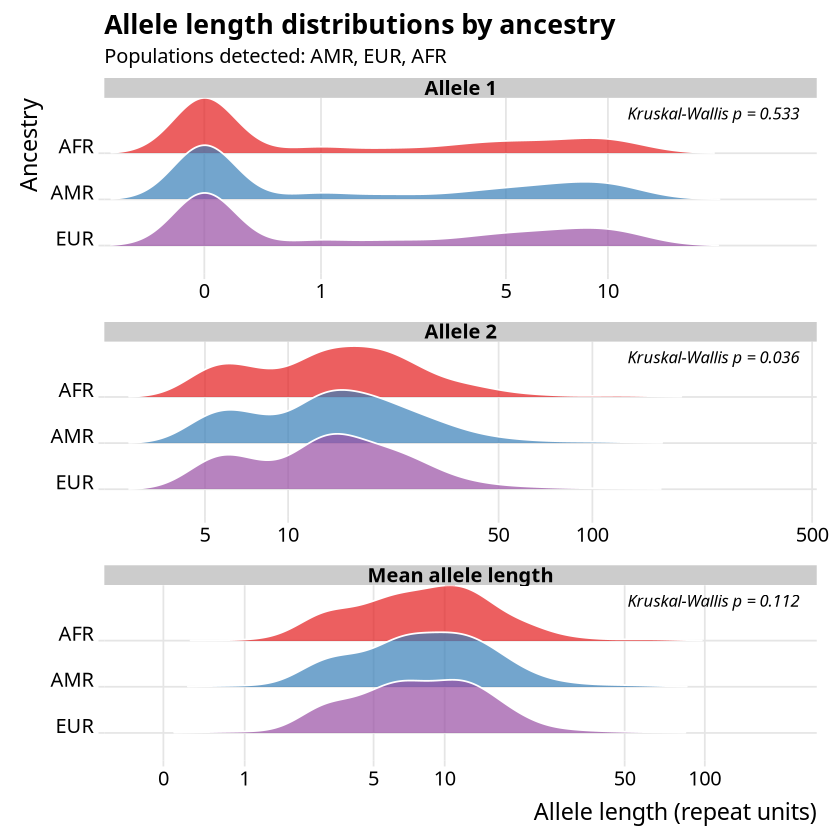

In [4]:
# ==========================================
# 1. PREPARE DATA
# ==========================================
# Filtering and formatting based on your imported 'allele_long'
allele_plot_log <- allele_long %>%
  filter(!is.na(value), value >= 0) %>%
  mutate(
    allele_type = recode(allele_type,
      "allele1_est" = "Allele 1",
      "allele2_est" = "Allele 2",
      "allele_mean" = "Mean allele length"
    ),
    # Ensuring the order matches the 5 populations reference (AFR at top)
    pop_ancestry = factor(pop_ancestry, levels = rev(c("AFR", "AMR", "EAS", "EUR", "SAS"))),
    value_log = log10(value + 1)
  )

# Color Palette
ancestry_colors <- c(
  AFR = "#E41A1C",
  AMR = "#377EB8",
  EAS = "#4DAF4A",
  EUR = "#984EA3",
  SAS = "#FF7F00"
)

# ==========================================
# 2. PREPARE STATS
# ==========================================
kw_pvals <- kw_alleles %>%
  mutate(
    allele_type = recode(variable,
      "allele1" = "Allele 1",
      "allele2" = "Allele 2",
      "allele_mean" = "Mean allele length"
    ),
    label = paste0("Kruskal-Wallis p = ", signif(p_value, 3))
  )

# ==========================================
# 3. GENERATE RIDGELINE PLOT
# ==========================================
p_allele_final <- ggplot(allele_plot_log, aes(x = value_log, y = pop_ancestry, fill = pop_ancestry)) +
  geom_density_ridges(
    alpha = 0.7,
    scale = 1.2,
    rel_min_height = 0.005,
    color = "white",
    bandwidth = 0.08
  ) +
  scale_x_continuous(
    breaks = log10(c(0, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 20000) + 1),
    labels = c("0", "1", "5", "10", "50", "100", "500", "1k", "5k", "10k", "20k"),
    expand = c(0.01, 0)
  ) +
  facet_wrap(~ allele_type, scales = "free_x", ncol = 1) +
  scale_fill_manual(values = ancestry_colors) +
  labs(
    title = "Allele length distributions by ancestry",
    subtitle = paste("Populations detected:", paste(ancestries_found, collapse = ", ")),
    x = "Allele length (repeat units)",
    y = "Ancestry"
  ) +
  theme_ridges(grid = TRUE) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold", size = 12),
    plot.title = element_text(face = "bold", size = 16),
    axis.title.x = element_text(hjust = 1, size = 14),
    panel.spacing = unit(0.8, "lines")
  ) +
  # Statistical annotation
  geom_text(
    data = kw_pvals,
    aes(x = Inf, y = Inf, label = label),
    inherit.aes = FALSE,
    hjust = 1.1,
    vjust = 1.8,
    size = 3.5,
    fontface = "italic"
  )
print(p_allele_final)

# ==========================================
# 4. SAVE OUTPUT
# ==========================================
output_path <- file.path(results_cat_data, "allele_distribution_ridgeline.png")

ggsave(
  filename = output_path,
  plot = p_allele_final,
  width = 11,
  height = 9,
  dpi = 300,
  bg = "white"
)

cat("\nSuccess: Plot saved to", output_path, "\n")

Descriptive statistics table for alleles

In [5]:
# =========================
# 0. LABELS
# =========================

ancestry_labels <- c(
  AFR = "African",
  AMR = "Admixed American",
  EAS = "East Asian",
  EUR = "European",
  SAS = "South Asian"
)

# Filter labels to only include ancestries present in the imported data
ancestry_labels <- ancestry_labels[names(ancestry_labels) %in% dist_summary$pop_ancestry]

# =========================
# 1. BUILD TABLE
# =========================

table_allele <- dist_summary %>%
  mutate(pop_ancestry = recode(pop_ancestry, !!!ancestry_labels)) %>%
  select(
    pop_ancestry,
    mean_a1, sd_a1, median_a1,
    mean_a2, sd_a2, median_a2,
    mean_mean, sd_mean, median_mean
  ) %>%
  gt() %>%
  fmt_number(columns = -pop_ancestry, decimals = 2) %>%
  cols_label(
    pop_ancestry = "Ancestry",
    
    mean_a1 = "Mean",
    sd_a1 = "SD",
    median_a1 = "Median",
    
    mean_a2 = "Mean",
    sd_a2 = "SD",
    median_a2 = "Median",
    
    mean_mean = "Mean",
    sd_mean = "SD",
    median_mean = "Median"
  ) %>%
  tab_spanner(label = "Allele 1", columns = c(mean_a1, sd_a1, median_a1)) %>%
  tab_spanner(label = "Allele 2", columns = c(mean_a2, sd_a2, median_a2)) %>%
  tab_spanner(label = "Mean allele", columns = c(mean_mean, sd_mean, median_mean)) %>%
  tab_header(
    title = "Descriptive statistics of allele lengths by ancestry"
  ) %>%
  tab_footnote(
    footnote = "SD: standard deviation"
  ) %>%
  # Scientific styling options
  tab_options(
    table.font.size = px(14),
    heading.title.font.size = px(18),
    column_labels.font.weight = "bold"
  )

# =========================
# 2. SAVE
# =========================

# Save to the directory defined in your categorical data import script
output_table_path <- file.path(results_cat_data, "table_allele_stats.html")

gtsave(table_allele, output_table_path)

cat("\nTable successfully saved to:", output_table_path, "\n")


Table successfully saved to: results/categorical_data/dataviz//table_allele_stats.html 


DBSCAN outliers distribution per sample by ancestry

Bubble plot


Bubble plot successfully saved to: results/categorical_data/dataviz//dbscan_bubble_outliers.png 


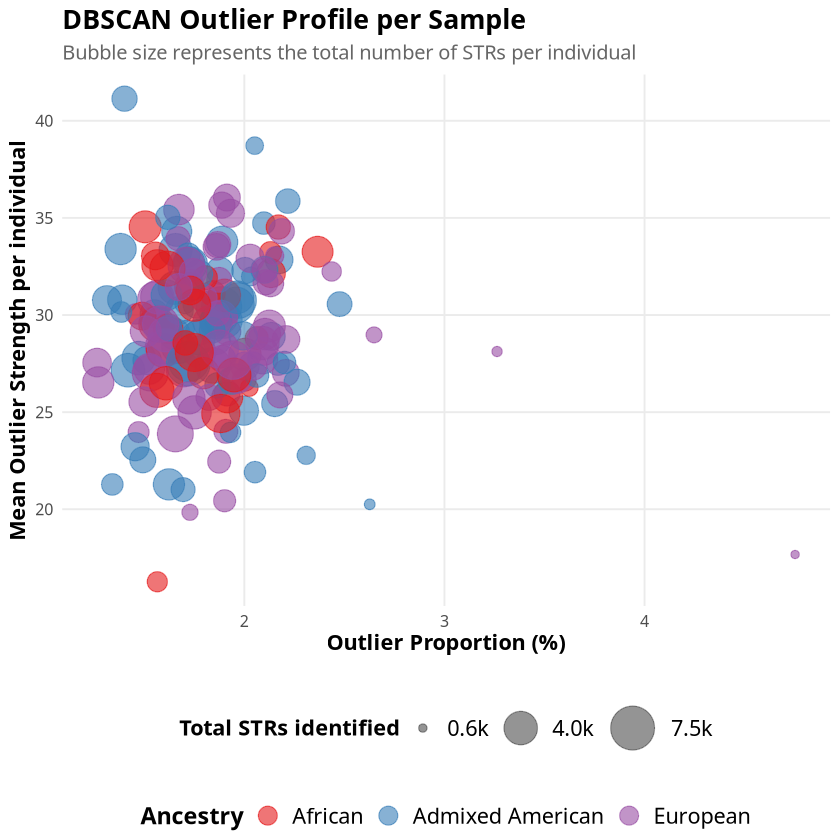

In [6]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================
dbscan_bubble <- dbscan_wide %>%
  mutate(
    # Set the order for the ancestry factors
    pop_ancestry = factor(pop_ancestry, levels = c("AFR", "AMR", "EAS", "EUR", "SAS")),
    
    # Convert proportion to percentage for the X-axis
    prop_outliers_pct = prop_outliers * 100
  )

# ==========================================
# 2. PLOT GENERATION
# ==========================================

# Dynamically calculate min/max based on the RAW total
min_strs <- min(dbscan_bubble$total_STRs_raw, na.rm = TRUE)
max_strs <- max(dbscan_bubble$total_STRs_raw, na.rm = TRUE)
mid_strs <- round((min_strs + max_strs) / 2)

p_bubble <- ggplot(dbscan_bubble, aes(x = prop_outliers_pct, 
                                      y = mean_outlier_strength, 
                                      color = pop_ancestry, 
                                      size = total_STRs_raw)) + 
  geom_point(alpha = 0.6, stroke = 0.5) +
  
  # Map the colors and labels defined in Section 0
  scale_color_manual(
    values = ancestry_colors, 
    labels = ancestry_labels,
    guide = guide_legend(override.aes = list(size = 5))
  ) +
  
  # Size scale formatting
  scale_size_continuous(
    limits = c(min_strs, max_strs),
    range = c(2, 12), 
    breaks = c(min_strs, mid_strs, max_strs),
    labels = label_number(
      scale = 1e-3,     
      suffix = "k",     
      accuracy = 0.1    
    ),
    guide = guide_legend(
      title = "Total STRs identified", 
      title.theme = element_text(face = "bold", size = 13),
      override.aes = list(color = "grey30")
    )
  ) +
  
  labs(
    title = "DBSCAN Outlier Profile per Sample",
    subtitle = "Bubble size represents the total number of STRs per individual",
    x = "Outlier Proportion (%)",
    y = "Mean Outlier Strength per individual",
    color = "Ancestry"
  ) +
  
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    legend.box = "vertical",
    legend.margin = margin(t = 15),
    legend.text = element_text(size = 13),       
    legend.title = element_text(size = 14, face = "bold"), 
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(color = "grey40", size = 12),
    axis.title = element_text(size = 13, face = "bold")
  )

# ==========================================
# 3. SAVE OUTPUT
# ==========================================
output_path <- file.path(results_cat_data, "dbscan_bubble_outliers.png")

ggsave(
  filename = output_path, 
  plot = p_bubble, 
  width = 9, 
  height = 8, 
  dpi = 400, 
  bg = "white"
)

cat("\nBubble plot successfully saved to:", output_path, "\n")
print(p_bubble)

Descriptive statistics table for dbscan

In [7]:
# =========================
# 0. PREPARE DATA
# =========================

# Ensure pop_ancestry is correctly labeled using your predefined ancestry_labels
# and that we are using the DBSCAN summary object (dist_outlier)
dbscan_table_data <- dist_outlier %>%
  mutate(pop_ancestry = recode(pop_ancestry, !!!ancestry_labels)) %>%
  select(
    pop_ancestry,
    n_samples,
    mean_prop,
    mean_strength
  )

# =========================
# 1. BUILD DBSCAN SUMMARY TABLE
# =========================

table_dbscan <- dbscan_table_data %>%
  gt() %>%
  # Format proportions as percentages and strength with 2 decimals
  fmt_number(columns = mean_strength, decimals = 2) %>%
  fmt_percent(columns = mean_prop, decimals = 2) %>%
  cols_label(
    pop_ancestry = "Ancestry",
    n_samples = "N (Samples)",
    mean_prop = "Mean Proportion (%)",
    mean_strength = "Mean Strength (Abs. Residual)"
  ) %>%
  tab_header(
    title = "DBSCAN Outlier Burden by Ancestry",
    subtitle = "Summary of frequency and magnitude of genomic deviations"
  ) %>%
  tab_footnote(
    footnote = "Mean Proportion: Average percentage of STRs identified as outliers per sample."
  ) %>%
  tab_footnote(
    footnote = "Mean Strength: Average absolute residual of outliers, representing the magnitude of deviation."
  ) %>%
  # Scientific styling options consistent with your previous tables
  tab_options(
    table.font.size = px(14),
    heading.title.font.size = px(18),
    column_labels.font.weight = "bold",
    table.width = pct(100)
  )

# =========================
# 2. SAVE
# =========================

# Save to your designated project directory
output_table_path_dbscan <- file.path(results_cat_data, "table_dbscan_stats.html")

gtsave(table_dbscan, output_table_path_dbscan)

cat("\nDBSCAN summary table successfully saved to:", output_table_path_dbscan, "\n")


DBSCAN summary table successfully saved to: results/categorical_data/dataviz//table_dbscan_stats.html 


Evaluate the standard deviation of allele2_est per genomic region

In [8]:
# ==========================================
# 4. CONSOLIDATION OF GLOBAL TESTS (KW)
# ==========================================
kw_final <- bind_rows(
  kw_alleles %>% 
    mutate(Analysis = "Allele Size Distribution"),
  kw_dbscan %>% 
    mutate(Analysis = "DBSCAN Outlier Analysis")
) %>% 
  mutate(Metric_Label = case_when(
    variable == "allele1_est" ~ "Allele 1",
    variable == "allele2_est" ~ "Allele 2",
    variable == "allele_mean" ~ "Allele Mean",
    variable == "prop_outliers" ~ "Outlier Proportion",
    variable == "mean_outlier_strength" ~ "Outlier Strength",
    TRUE ~ variable
  ))

# ==========================================
# 5. DETAILED DUNN TEST PREPARATION
# ==========================================
dunn_alleles_path <- file.path(results_import, "alleles_dunn_results.csv")
dunn_dbscan_path  <- file.path(results_import, "dbscan_dunn_results.csv")

dunn_list <- list()
if (file.exists(dunn_alleles_path)) dunn_list[[1]] <- read_csv(dunn_alleles_path, show_col_types = FALSE)
if (file.exists(dunn_dbscan_path))  dunn_list[[2]] <- read_csv(dunn_dbscan_path, show_col_types = FALSE)

if (length(dunn_list) > 0) {
  dunn_all <- bind_rows(dunn_list) %>%
    # Create a readable label for pairwise comparisons
    mutate(comparison = paste0(group1, " vs ", group2)) %>%
    # Select and rename columns for joining
    select(variable, comparison, p.adj, p.adj.signif)
} else {
  dunn_all <- tibble(
    variable = character(), 
    comparison = character(), 
    p.adj = numeric(), 
    p.adj.signif = character()
  )
}

# ==========================================
# 6. INTEGRATED TABLE CREATION (FULL METRICS)
# ==========================================

# Merging data: each metric will be associated with its respective Dunn rows
final_table_data <- kw_final %>%
  left_join(dunn_all, by = "variable") %>%
  # Organize by analysis group
  arrange(Analysis, Metric_Label)

stats_table <- final_table_data %>%
  gt(groupname_col = "Analysis", rowname_col = "Metric_Label") %>%
  tab_header(
    title = "Complete Statistical Report: Genomic Variants & DBSCAN",
    subtitle = "Kruskal-Wallis Global Tests and Detailed Dunn Post-hoc Results"
  ) %>%
  # Number formatting
  fmt_number(columns = statistic, decimals = 3) %>%
  fmt_scientific(columns = c(p_value, p.adj), decimals = 3) %>%
  # Column labeling
  cols_label(
    statistic = "Kruskal-Wallis Statistic",
    p_value = "Kruskal-Wallis p-value",
    comparison = "Pairwise Comparison",
    p.adj = "Dunn p-adj (BH)",
    p.adj.signif = "Sig."
  ) %>%
  # Hide technical columns
  cols_hide(columns = variable) %>%
  # Style: Highlight significant p-values (KW and Dunn)
  tab_style(
    style = cell_text(weight = "bold", color = "#1a5e1a"),
    locations = cells_body(columns = p_value, rows = p_value < 0.05)
  ) %>%
  tab_style(
    style = cell_text(style = "italic", color = "#1a5e1a"),
    locations = cells_body(columns = p.adj, rows = p.adj < 0.05)
  ) %>%
  # Table aesthetic options
  tab_options(
    row_group.background.color = "#f4f4f4",
    table.font.size = "12px",
    data_row.padding = px(3)
  ) %>%
  # Replace NAs (where KW was not significant and no Dunn test was performed)
  sub_missing(columns = everything(), missing_text = "-")

# ==========================================
# 7. EXPORT
# ==========================================
gtsave(stats_table, file.path(results_cat_data, "statistical_summaryKW_alleles+dbscan.html"))

# Dataviz (High-Resolution)

Publication‑ready table for ancestry proportions by region

In [9]:
# ==========================================
# 1. LOAD DATA 
# ==========================================

# Calculate summary metrics (using plotdata_region_sample)
metrics_summary <- plotdata_region_sample %>%
  group_by(region) %>%
  summarise(
    Avg_Outlier_Count = mean(n_outliers, na.rm = TRUE),
    Avg_Outlier_Strength = mean(outlier_strength, na.rm = TRUE)
  )

# ==========================================
# 2. DATA TRANSFORMATION
# ==========================================

# Ancestry Proportions Transformation
df_ancestry_wide <- ancestry_region_wide %>%
  pivot_longer(
    cols = -region, 
    names_to = "Metric", 
    values_to = "value"
  ) %>%
  mutate(Metric = case_when(
    Metric == "AFR" ~ "African (%)",
    Metric == "AMR" ~ "Admixed American (%)",
    Metric == "EAS" ~ "East Asian (%)",
    Metric == "EUR" ~ "European (%)",
    Metric == "SAS" ~ "South Asian (%)",
    TRUE ~ Metric
  )) %>%
  mutate(value = value * 100)

# Outlier Metrics Transformation
df_metrics_wide <- metrics_summary %>%
  pivot_longer(
    cols = -region,
    names_to = "Metric",
    values_to = "value"
  ) %>%
  mutate(Metric = case_when(
    Metric == "Avg_Outlier_Count" ~ "Average Outlier Count",
    Metric == "Avg_Outlier_Strength" ~ "Average Outlier Strength",
    TRUE ~ Metric
  ))

# Combine datasets into a final wide format for the table
df_final <- bind_rows(df_ancestry_wide, df_metrics_wide) %>%
  pivot_wider(
    id_cols = Metric, 
    names_from = region, 
    values_from = value
  )

# ==========================================
# 3. GT TABLE CREATION
# ==========================================

tabela_final <- df_final %>%
  gt() %>%
  tab_header(
    title = "Regional Genomic Summary",
    subtitle = "Ancestry profiles and DBSCAN outlier signals"
  ) %>%
  fmt_number(
    columns = where(is.numeric), 
    decimals = 2
  ) %>%
  cols_label(Metric = "Analysis Parameters") %>%
  
  # Grouping rows for better organization
  tab_row_group(
    label = "DBSCAN Outlier Signals",
    rows = Metric %in% c("Average Outlier Count", "Average Outlier Strength")
  ) %>%
  tab_row_group(
    label = "Ancestry Proportions",
    rows = grepl("%", Metric)
  ) %>%
  
  # Visual Styling
  tab_style(
    style = cell_text(weight = "bold"),
    locations = cells_body(columns = Metric)
  ) %>%
  opt_table_outline() %>%
  tab_options(
    heading.title.font.size = "18px",
    table.font.size = "13px",
    column_labels.font.weight = "bold",
    data_row.padding = px(5)
  ) %>%
  
  # Scientific Annotation
  tab_footnote(
    footnote = "Outlier Strength represents the mean magnitude of residuals for confirmed outliers per region.",
    locations = cells_body(columns = Metric, rows = Metric == "Average Outlier Strength")
  )

# ==========================================
# 4. SAVING
# ==========================================

# Using results_dir_high defined in your import script
output_path <- file.path(results_dir_high, "genomic_summary_per_region.html")
gtsave(tabela_final, output_path)

cat("Table updated! Saved at:", output_path, "\n")

Table updated! Saved at: results/high_resolution/dataviz//genomic_summary_per_region.html 


Individual heatmaps per metric (using heatmap)

In [10]:
# ==========================================
# 1. DATA PREPARATION (Cleaning Labels)
# ==========================================
corr_data_clean <- corr_data %>%
  mutate(
    # 1. Initial cleaning: replace underscores with spaces
    region_clean = str_replace_all(region, "_", " "),
    
    # 2. Specific mapping for technical genomic terms
    region = case_when(
      str_detect(region, "three_prime_utr") ~ "3' UTR",
      str_detect(region, "five_prime_utr")  ~ "5' UTR",
      TRUE ~ str_to_sentence(region_clean)
    ),
    
    # Clean Ancestry names
    ancestry = str_to_upper(ancestry),
    
    # Map Metrics to friendly names
    metric_name = case_when(
      metric == "outlier_prop" ~ "Outlier Proportion",
      metric == "outlier_strength" ~ "Outlier Strength",
      TRUE ~ str_to_title(str_replace_all(metric, "_", " "))
    )
  ) %>%
  select(-region_clean)

# ==========================================
# 2. LOOP FOR HEATMAPS 
# ==========================================
metrics <- unique(corr_data_clean$metric)

for (m in metrics) {
  
  df_metric <- corr_data_clean %>% filter(metric == m)
  curr_display_name <- first(df_metric$metric_name)
  
  # Prepare Matrix: Ancestry (Rows) vs Region (Columns)
  df_hm <- df_metric %>%
    select(region, ancestry, estimate) %>%
    pivot_wider(names_from = region, values_from = estimate, values_fill = NA) %>%
    column_to_rownames(var = "ancestry")
  
  mat <- as.matrix(df_hm)
  
  # Handle scale for color balance
  max_abs_val <- max(abs(mat), na.rm = TRUE)
  if(max_abs_val == 0 || is.infinite(max_abs_val)) max_abs_val <- 0.1 
  
  breaks <- seq(-max_abs_val, max_abs_val, length.out = 101)
  colors <- colorRampPalette(rev(brewer.pal(11, "RdBu")))(100)
  
  hm_file_name <- paste0("heatmap_correlation_", m, ".png")
  hm_output_path <- file.path(results_dir_high, hm_file_name)
  
  pheatmap(
    mat,
    main = paste0("Spearman Correlation (rho): ", curr_display_name, "\n(Ancestry vs Genomic Regions)"),
    cluster_rows = TRUE,
    cluster_cols = TRUE,
    color = colors,
    breaks = breaks,
    fontsize = 10,
    angle_col = 45,
    display_numbers = FALSE,
    filename = hm_output_path,
    width = 10,
    height = 7
  )
  
  cat("Saved heatmap to:", hm_output_path, "\n")
}

# ==========================================
# 3. GENERATE SINGLE SYNTHESIZED TABLE
# ==========================================

table_data_unified <- corr_data_clean %>%
  mutate(significance = ifelse(p_adj < 0.05, "Yes", "No")) %>%
  select(region, ancestry, metric_name, estimate, p_adj, significance) %>%
  pivot_wider(
    names_from = metric_name,
    values_from = c(estimate, p_adj, significance)
  ) %>%
  arrange(region, ancestry)

tabela_unica <- table_data_unified %>%
  gt(groupname_col = "region") %>% 
  tab_header(
    title = "Comprehensive Correlation Analysis",
    subtitle = "Spearman rho and adjusted p-values for outlier signals"
  ) %>%
  
  tab_spanner(
    label = "Outlier Proportion",
    columns = ends_with("Outlier Proportion")
  ) %>%
  tab_spanner(
    label = "Outlier Strength",
    columns = ends_with("Outlier Strength")
  ) %>%
  
  cols_label(
    ancestry = "Ancestry",
    `estimate_Outlier Proportion` = "Spearman (ρ)",
    `p_adj_Outlier Proportion` = "p-adj",
    `significance_Outlier Proportion` = "Sig.",
    `estimate_Outlier Strength` = "Spearman (ρ)",
    `p_adj_Outlier Strength` = "p-adj",
    `significance_Outlier Strength` = "Sig."
  ) %>%
  
  fmt_number(columns = starts_with("estimate"), decimals = 3) %>%
  fmt_scientific(columns = starts_with("p_adj"), decimals = 2) %>%
  
  opt_table_lines("default") %>%
  tab_options(
    table.font.size = "13px",
    column_labels.font.weight = "bold",
    row_group.font.weight = "bold",
    row_group.background.color = "#F8F8F8"
  ) %>%
  
  tab_footnote(
    footnote = "Significance determined by Benjamini-Hochberg adjusted p-value < 0.05.",
    locations = cells_column_labels(columns = starts_with("significance"))
  )

table_output_path <- file.path(results_dir_high, "comprehensive_correlation_table.html")
gtsave(tabela_unica, table_output_path)

cat("\nSuccessfully saved synthesized correlation table to:", table_output_path, "\n")

Saved heatmap to: results/high_resolution/dataviz//heatmap_correlation_outlier_prop.png 
Saved heatmap to: results/high_resolution/dataviz//heatmap_correlation_outlier_strength.png 

Successfully saved synthesized correlation table to: results/high_resolution/dataviz//comprehensive_correlation_table.html 
